In [ ]:
# ============================================================
# FORENSIC IDENTIFICATION USING MAHALANOBIS DISTANCE & DFA
# Howells Craniometric Dataset
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

from scipy.spatial.distance import mahalanobis
from scipy.stats import chi2

import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
# ============================================================
# UPLOAD HOWELLS DATASET
# ============================================================

uploaded = files.upload()

filename = list(uploaded.keys())[0]

print("Uploaded file:", filename)

# Read CSV
df = pd.read_csv(filename)

print("\nDataset shape:")
print(df.shape)

print("\nFirst 5 observations:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

Saving Howell.csv to Howell.csv
Uploaded file: Howell.csv

Dataset shape:
(2524, 86)

First 5 observations:


,ID,Sex,PopNum,Population,GOL,NOL,BNL,BBH,XCB,XFB,...,FRA,PAA,OCA,RFA,RPA,ROA,BSA,SBA,SLA,TBA
0,1,M,1,NORSE,189,185,100,135,143,120,...,134,133,117,0,0,0,0,0,0,0
1,2,M,1,NORSE,182,178,102,139,145,120,...,128,134,119,0,0,0,0,0,0,0
2,3,M,1,NORSE,191,187,102,123,140,114,...,129,137,111,0,0,0,0,0,0,0
3,4,M,1,NORSE,191,188,100,127,141,123,...,128,135,108,0,0,0,0,0,0,0
4,5,M,1,NORSE,178,177,97,128,138,117,...,133,130,111,0,0,0,0,0,0,0



Column names:
['ID', 'Sex', 'PopNum', 'Population', 'GOL', 'NOL', 'BNL', 'BBH', 'XCB', 'XFB', 'ZYB', 'AUB', 'WCB', 'ASB', 'BPL', 'NPH', 'NLH', 'JUB', 'NLB', 'MAB', 'MDH', 'MDB', 'OBH', 'OBB', 'DKB', 'NDS', 'WNB', 'SIS', 'ZMB', 'SSS', 'FMB', 'NAS', 'EKB', 'DKS', 'IML', 'XML', 'MLS', 'WMH', 'SOS', 'GLS', 'STB', 'FRC', 'FRS', 'FRF', 'PAC', 'PAS', 'PAF', 'OCC', 'OCS', 'OCF', 'FOL', 'NAR', 'SSR', 'PRR', 'DKR', 'ZOR', 'FMR', 'EKR', 'ZMR', 'AVR', 'BRR', 'VRR', 'LAR', 'OSR', 'BAR', 'NAA', 'PRA', 'BAA', 'NBA', 'BBA', 'BRA', 'SSA', 'NFA', 'DKA', 'NDA', 'SIA', 'FRA', 'PAA', 'OCA', 'RFA', 'RPA', 'ROA', 'BSA', 'SBA', 'SLA', 'TBA']


In [ ]:
# ============================================================
# BASIC DATASET INFORMATION
# ============================================================

print("Number of observations:", df.shape[0])
print("Number of variables:", df.shape[1])

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False).head(20))

Number of observations: 2524
Number of variables: 86

Data types:
ID             int64
Sex           object
PopNum         int64
Population    object
GOL            int64
               ...  
ROA            int64
BSA            int64
SBA            int64
SLA            int64
TBA            int64
Length: 86, dtype: object

Missing values:


,0
ID,0
Sex,0
PopNum,0
Population,0
GOL,0
NOL,0
BNL,0
BBH,0
XCB,0
XFB,0


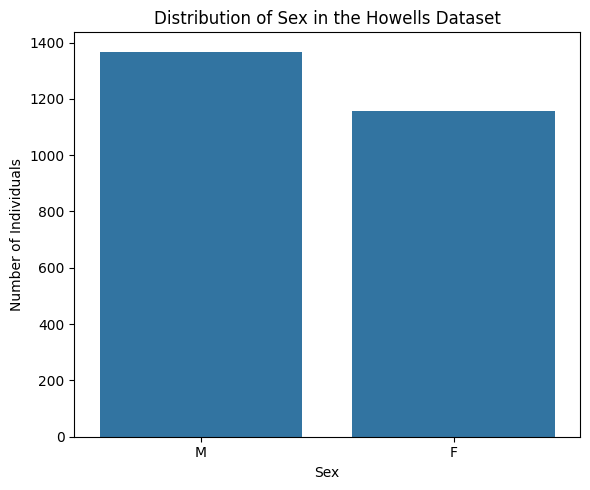

In [ ]:
plt.figure(figsize=(6, 5))

sns.countplot(
    data=df,
    x="Sex"
)

plt.title("Distribution of Sex in the Howells Dataset")
plt.xlabel("Sex")
plt.ylabel("Number of Individuals")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STEP 2: DEFINE VARIABLES
# ============================================================

non_measurement = ["ID", "Sex", "PopNum", "Population"]

measurement_vars = [
    col for col in df.columns
    if col not in non_measurement
]

print("Number of cranial measurements:", len(measurement_vars))
print("\nMeasurements:")
print(measurement_vars)

Number of cranial measurements: 82

Measurements:
['GOL', 'NOL', 'BNL', 'BBH', 'XCB', 'XFB', 'ZYB', 'AUB', 'WCB', 'ASB', 'BPL', 'NPH', 'NLH', 'JUB', 'NLB', 'MAB', 'MDH', 'MDB', 'OBH', 'OBB', 'DKB', 'NDS', 'WNB', 'SIS', 'ZMB', 'SSS', 'FMB', 'NAS', 'EKB', 'DKS', 'IML', 'XML', 'MLS', 'WMH', 'SOS', 'GLS', 'STB', 'FRC', 'FRS', 'FRF', 'PAC', 'PAS', 'PAF', 'OCC', 'OCS', 'OCF', 'FOL', 'NAR', 'SSR', 'PRR', 'DKR', 'ZOR', 'FMR', 'EKR', 'ZMR', 'AVR', 'BRR', 'VRR', 'LAR', 'OSR', 'BAR', 'NAA', 'PRA', 'BAA', 'NBA', 'BBA', 'BRA', 'SSA', 'NFA', 'DKA', 'NDA', 'SIA', 'FRA', 'PAA', 'OCA', 'RFA', 'RPA', 'ROA', 'BSA', 'SBA', 'SLA', 'TBA']


In [ ]:
# ============================================================
# STEP 3: TREAT ZERO AS MISSING
# ============================================================

data = df.copy()

data[measurement_vars] = data[measurement_vars].replace(0, np.nan)

print("Missing percentage:")
missing_pct = data[measurement_vars].isna().mean() * 100

print(
    missing_pct
    .sort_values(ascending=False)
    .round(2)
)

Missing percentage:
TBA    26.23
BSA    26.23
ROA    26.23
RFA    26.23
RPA    26.23
       ...  
NDA     0.00
DKA     0.00
NFA     0.00
SSA     0.00
OCA     0.00
Length: 82, dtype: float64


In [ ]:
# ============================================================
# STEP 4: TRAIN / TEST SPLIT
# ============================================================

train_df, test_df = train_test_split(
    data,
    test_size=0.20,
    stratify=data["Sex"],
    random_state=42
)

print("Training size:", train_df.shape)
print("Testing size :", test_df.shape)

print("\nTraining sex distribution:")
print(train_df["Sex"].value_counts())

print("\nTesting sex distribution:")
print(test_df["Sex"].value_counts())

Training size: (2019, 86)
Testing size : (505, 86)

Training sex distribution:
Sex
M    1094
F     925
Name: count, dtype: int64

Testing sex distribution:
Sex
M    274
F    231
Name: count, dtype: int64


In [ ]:
# ============================================================
# STEP 5: REMOVE HIGH-MISSINGNESS VARIABLES
# ============================================================

train_missing = train_df[measurement_vars].isna().mean()

selected_missing = train_missing[
    train_missing <= 0.20
].index.tolist()

print("Variables before filtering:", len(measurement_vars))
print("Variables after missingness filter:", len(selected_missing))

print("\nRemoved variables:")
print(
    sorted(
        set(measurement_vars) - set(selected_missing)
    ))

Variables before filtering: 82
Variables after missingness filter: 71

Removed variables:
['BAR', 'BRR', 'BSA', 'LAR', 'OSR', 'RFA', 'ROA', 'RPA', 'SBA', 'SLA', 'TBA']


In [ ]:
# ============================================================
# STEP 6: MEDIAN IMPUTATION
# ============================================================

train_X = train_df[selected_missing].copy()
test_X = test_df[selected_missing].copy()

# Calculate medians ONLY from training data
train_medians = train_X.median()

train_X = train_X.fillna(train_medians)
test_X = test_X.fillna(train_medians)

print("Remaining missing values in training:",
      train_X.isna().sum().sum())

print("Remaining missing values in testing:",
      test_X.isna().sum().sum())# ============================================================
# STEP 7: CORRELATION FILTERING
# ============================================================

corr_matrix = train_X.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Threshold
corr_threshold = 0.90

to_drop = [
    column
    for column in upper.columns
    if any(upper[column] > corr_threshold)
]

train_X_corr = train_X.drop(columns=to_drop)
test_X_corr = test_X.drop(columns=to_drop)

print("Variables before correlation filtering:",
      train_X.shape[1])

print("Variables removed due to high correlation:",
      len(to_drop))

print("Variables remaining:",
      train_X_corr.shape[1])

print("\nRemoved variables:")
print(to_drop)

Remaining missing values in training: 0
Remaining missing values in testing: 0
Variables before correlation filtering: 71
Variables removed due to high correlation: 11
Variables remaining: 60

Removed variables:
['NOL', 'EKB', 'PRR', 'DKR', 'ZOR', 'EKR', 'ZMR', 'AVR', 'SSA', 'NFA', 'DKA']


In [ ]:
# ============================================================
# STEP 8: STANDARDIZATION
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(train_X_corr)
X_test_scaled = scaler.transform(test_X_corr)

y_train = train_df["Sex"]
y_test = test_df["Sex"]

In [ ]:
# ============================================================
# STEP 9: LDA-BASED VARIABLE SELECTION
# ============================================================
from sklearn.feature_selection import SequentialFeatureSelector
lda = LinearDiscriminantAnalysis()

sfs = SequentialFeatureSelector(
    lda,
    n_features_to_select=10,
    direction="forward",
    scoring="accuracy",
    cv=5,
    n_jobs=-1
)

sfs.fit(X_train_scaled, y_train)

selected_mask = sfs.get_support()

selected_variables = train_X_corr.columns[selected_mask].tolist()

print("\nSelected variables:")
print(selected_variables)

print("\nNumber of selected variables:",
      len(selected_variables))


Selected variables:
['ZYB', 'MDH', 'ZMB', 'MLS', 'SOS', 'FRC', 'PAF', 'FOL', 'NAR', 'PAA']

Number of selected variables: 10


In [ ]:
# ============================================================
# STEP 10: DISPLAY SELECTED VARIABLES
# ============================================================

selection_table = pd.DataFrame({
    "Variable": train_X_corr.columns,
    "Selected": selected_mask
})

print(
    selection_table[
        selection_table["Selected"] == True
    ]
)

   Variable  Selected
5       ZYB      True
15      MDH      True
23      ZMB      True
30      MLS      True
32      SOS      True
35      FRC      True
40      PAF      True
44      FOL      True
45      NAR      True
58      PAA      True


In [ ]:
# ============================================================
# STEP 11: FINAL SELECTED DATA
# ============================================================

X_train_selected = train_X_corr[selected_variables].copy()
X_test_selected = test_X_corr[selected_variables].copy()

print("Final training matrix:",
      X_train_selected.shape)

print("Final testing matrix:",
      X_test_selected.shape)

Final training matrix: (2019, 10)
Final testing matrix: (505, 10)


In [ ]:
# ============================================================
# STEP 12: MAHALANOBIS DISTANCE
# ============================================================

Xtr = X_train_selected.values

male = X_train_selected[y_train.values == "M"]
female = X_train_selected[y_train.values == "F"]

n_M = len(male)
n_F = len(female)

# Group means
mu_M = male.mean(axis=0)
mu_F = female.mean(axis=0)

# Group covariance matrices
S_M = np.cov(male, rowvar=False)
S_F = np.cov(female, rowvar=False)

# Pooled covariance matrix
S_p = (
    (n_M - 1) * S_M +
    (n_F - 1) * S_F
) / (n_M + n_F - 2)

# Inverse
S_p_inv = np.linalg.pinv(S_p)

print("Male sample size:", n_M)
print("Female sample size:", n_F)

print("\nPooled covariance matrix shape:",
      S_p.shape)

Male sample size: 1094
Female sample size: 925

Pooled covariance matrix shape: (10, 10)


In [ ]:
# ============================================================
# STEP 13: MAHALANOBIS CLASSIFICATION
# ============================================================

def mahalanobis_squared(x, mean, cov_inv):
    diff = x - mean
    return diff @ cov_inv @ diff


def classify_mahalanobis(X):

    predictions = []

    D_M_values = []
    D_F_values = []

    for x in X:

        D_M = mahalanobis_squared(
            x,
            mu_M.values,
            S_p_inv
        )

        D_F = mahalanobis_squared(
            x,
            mu_F.values,
            S_p_inv
        )

        D_M_values.append(D_M)
        D_F_values.append(D_F)

        if D_M < D_F:
            predictions.append("M")
        else:
            predictions.append("F")

    return predictions, D_M_values, D_F_values

In [ ]:
# ============================================================
# STEP 13: MAHALANOBIS CLASSIFICATION
# ============================================================

def mahalanobis_squared(x, mean, cov_inv):
    diff = x - mean
    return diff @ cov_inv @ diff


def classify_mahalanobis(X):

    predictions = []

    D_M_values = []
    D_F_values = []

    for x in X:

        D_M = mahalanobis_squared(
            x,
            mu_M.values,
            S_p_inv
        )

        D_F = mahalanobis_squared(
            x,
            mu_F.values,
            S_p_inv
        )

        D_M_values.append(D_M)
        D_F_values.append(D_F)

        if D_M < D_F:
            predictions.append("M")
        else:
            predictions.append("F")

    return predictions, D_M_values, D_F_values

In [ ]:
# ============================================================
# STEP 14: TEST MAHALANOBIS CLASSIFICATION
# ============================================================

mahal_pred, D_M, D_F = classify_mahalanobis(
    X_test_selected.values
)

mahal_accuracy = accuracy_score(
    y_test,
    mahal_pred
)

print("Mahalanobis classification accuracy:",
      round(mahal_accuracy, 4))

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        mahal_pred,
        labels=["M", "F"]
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        mahal_pred
    )
)

Mahalanobis classification accuracy: 0.8931

Confusion Matrix:
[[239  35]
 [ 19 212]]

Classification Report:
              precision    recall  f1-score   support

           F       0.86      0.92      0.89       231
           M       0.93      0.87      0.90       274

    accuracy                           0.89       505
   macro avg       0.89      0.90      0.89       505
weighted avg       0.90      0.89      0.89       505



In [ ]:
# ============================================================
# STEP 15: LDA
# ============================================================

lda_final = LinearDiscriminantAnalysis()

lda_final.fit(
    X_train_selected,
    y_train
)

lda_pred = lda_final.predict(
    X_test_selected
)

lda_accuracy = accuracy_score(
    y_test,
    lda_pred
)

print("LDA accuracy:",
      round(lda_accuracy, 4))

print("\nLDA Confusion Matrix:")
print(
    confusion_matrix(
        y_test,
        lda_pred,
        labels=["M", "F"]
    )
)

LDA accuracy: 0.8871

LDA Confusion Matrix:
[[239  35]
 [ 22 209]]


In [ ]:
# ============================================================
# STEP 15: LDA
# ============================================================

lda_final = LinearDiscriminantAnalysis()

lda_final.fit(
    X_train_selected,
    y_train
)

lda_pred = lda_final.predict(
    X_test_selected
)

lda_accuracy = accuracy_score(
    y_test,
    lda_pred
)

print("LDA accuracy:",
      round(lda_accuracy, 4))

print("\nLDA Confusion Matrix:")
print(
    confusion_matrix(
        y_test,
        lda_pred,
        labels=["M", "F"]
    )
)
# ============================================================
# STEP 16: FINAL COMPARISON
# ============================================================

comparison = pd.DataFrame({
    "Method": [
        "Mahalanobis Distance",
        "Linear Discriminant Analysis"
    ],

    "Accuracy": [
        mahal_accuracy,
        lda_accuracy
    ]
})

print(comparison)


LDA accuracy: 0.8871

LDA Confusion Matrix:
[[239  35]
 [ 22 209]]
                         Method  Accuracy
0          Mahalanobis Distance  0.893069
1  Linear Discriminant Analysis  0.887129


In [ ]:
lda_eq = LinearDiscriminantAnalysis(priors=[0.5, 0.5])
lda_eq.fit(X_train_selected, y_train)
print(confusion_matrix(y_test, lda_eq.predict(X_test_selected), labels=["M","F"]))
# expect [[239 35] [19 212]]

[[239  35]
 [ 19 212]]
